<a href="https://colab.research.google.com/github/fknbtrd/netology_homework/blob/main/LinearRegression%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Проверка данных

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


пропусков нет

Делим на обучающую и тестовую выборку

In [5]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Базовая модель (со всеми признаками)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Базовая модель")
print("RMSE:", rmse)
print("R2:", r2)

Базовая модель
RMSE: 0.7455813830127764
R2: 0.5757877060324508


Распределение целевой переменной

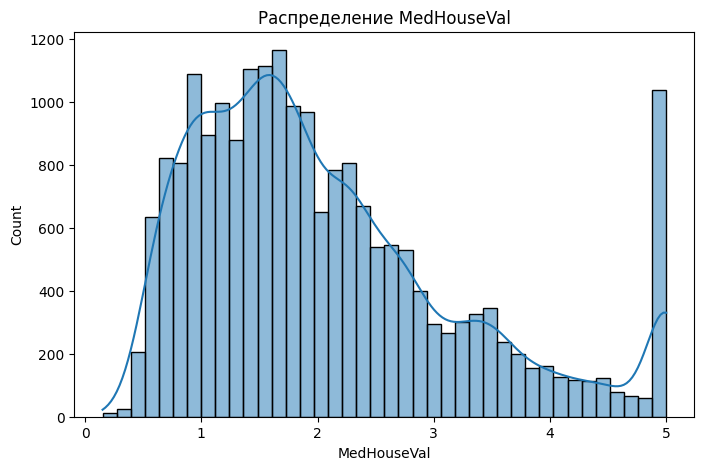

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['MedHouseVal'], bins=40, kde=True)
plt.title("Распределение MedHouseVal")
plt.show()

распределение несимметричное - возможны выбросы

Корреляционная матрица

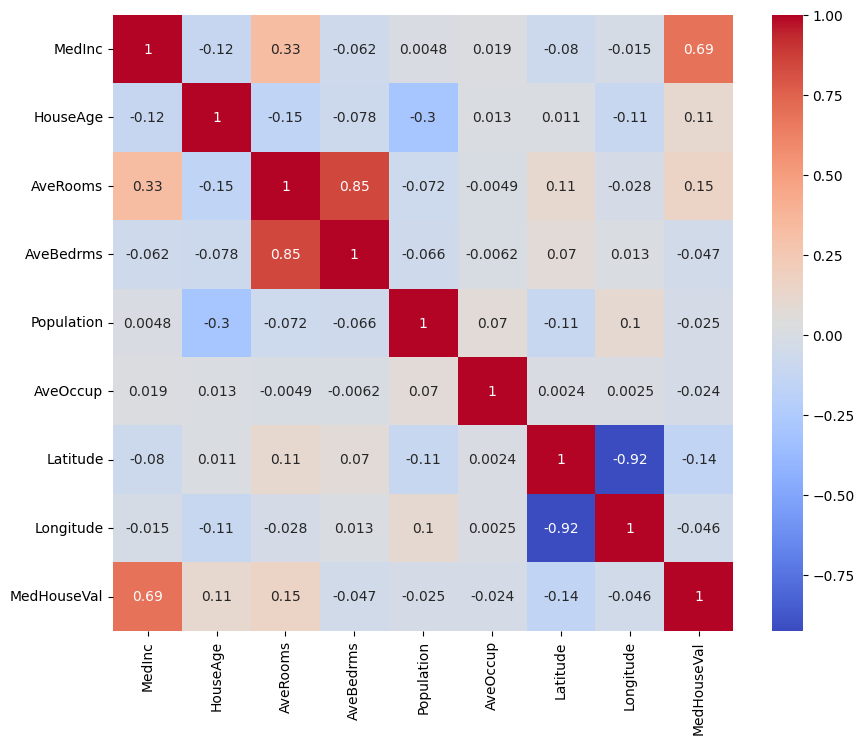

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

MedInc сильно влияет на цену
Population и AveOccup почти не влияют, поэтому можно убрать

Модель с отобранными признаками

In [9]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']

X = df[features]
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train, y_train)

y_pred = model2.predict(X_test)

rmse2 = np.sqrt(mean_squared_error(y_test, y_pred))
r2_2 = r2_score(y_test, y_pred)

print("Модель с отбором признаков")
print("RMSE:", rmse2)
print("R2:", r2_2)

Модель с отбором признаков
RMSE: 0.7463001660559117
R2: 0.5749693819995396


Удаление выбросов

In [10]:
df2 = df[features + ['MedHouseVal']]

Q1 = df2.quantile(0.25)
Q3 = df2.quantile(0.75)
IQR = Q3 - Q1

df2 = df2[~((df2 < (Q1 - 1.5 * IQR)) | (df2 > (Q3 + 1.5 * IQR))).any(axis=1)]

Модель без выбросов

In [11]:
X = df2[features]
y = df2['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model3 = LinearRegression()
model3.fit(X_train, y_train)

y_pred = model3.predict(X_test)

rmse3 = np.sqrt(mean_squared_error(y_test, y_pred))
r2_3 = r2_score(y_test, y_pred)

print("Модель без выбросов")
print("RMSE:", rmse3)
print("R2:", r2_3)

Модель без выбросов
RMSE: 0.5987083349988533
R2: 0.5859442818059051


Преобразование признака

In [12]:
df2['MedInc_log'] = np.log1p(df2['MedInc'])

features2 = features + ['MedInc_log']

X = df2[features2]
y = df2['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model4 = LinearRegression()
model4.fit(X_train, y_train)

y_pred = model4.predict(X_test)

rmse4 = np.sqrt(mean_squared_error(y_test, y_pred))
r2_4 = r2_score(y_test, y_pred)

print("Модель с преобразованием")
print("RMSE:", rmse4)
print("R2:", r2_4)

Модель с преобразованием
RMSE: 0.5986275863294622
R2: 0.5860559628755249


Сравнение моделей

In [13]:
results = pd.DataFrame({
    'Модель': ['Базовая', 'Отбор признаков', 'Без выбросов', 'С преобразованием'],
    'RMSE': [rmse, rmse2, rmse3, rmse4],
    'R2': [r2, r2_2, r2_3, r2_4]
})

results

,Модель,RMSE,R2
0,Базовая,0.745581,0.575788
1,Отбор признаков,0.746300,0.574969
2,Без выбросов,0.598708,0.585944
3,С преобразованием,0.598628,0.586056


Что сделано:

1. Проверены пропуски загруженной модели.

2. Построена базовая модель линейной регрессии на всех признаках.

3. С помощью корреляционной матрицы удалены признаки, слабо влияющие на целевую переменную.

4. Удалены выбросы методом межквартильного размаха, это улучшило качество модели.

5. Применен логарифм к признаку MedInc, это тоже немного улучшило результат.

6. Лучшие результаты показала модель после очистки данных и преобразования признаков.

Выводы:
1. Линейная регрессия справляется с задачей, но не идеально: ошибки все еще есть, R2 не равен 1.
2. Возможно, зависимость не полностью линейная, поэтому можно было бы использовать другие модели, которые могут работать со сложными зависимостями и нелинейностью. Линейная модель предполагает, что у цены есть прямая зависимость, но в реальности это не так.